In [27]:
import pandas as pd
import numpy as np
import geopandas as gdp

In [16]:
anjuke= pd.read_csv('UTSEUS-anjuke-real-estate(1).csv')

In [54]:
poi_df = pd.read_csv('shanghaiPOI2017.csv', 
                     sep=';',           # séparateur de colonnes
                     decimal=',',       # virgule comme séparateur décimal
                     encoding='utf-8',
                     on_bad_lines='skip')

C:\Users\pc\AppData\Local\Temp\ipykernel_22320\3998416121.py:1: DtypeWarning: Columns (7,16,17,19) have mixed types. Specify dtype option on import or set low_memory=False.
  poi_df = pd.read_csv('shanghaiPOI2017.csv',


In [12]:
anjuke.describe()

NameError: name 'anjuke' is not defined

In [55]:
anjuke_lon_z= (anjuke.longitude - anjuke.longitude.mean())/anjuke.longitude.std() 

In [56]:
anjuke_lat_z= (anjuke.latitude - anjuke.latitude.mean())/anjuke.latitude.std() 

In [57]:
an_df = anjuke[(anjuke_lon_z<3) & (anjuke_lat_z<3)]

In [25]:
an_df.describe()

,longitude,latitude,bedroom,room,surface,price,onesquaremeter,done
count,460112.000000,460112.000000,460112.000000,460112.000000,460112.000000,4.601120e+05,4.601120e+05,460112.000000
mean,121.381603,31.165843,2.337618,1.646643,104.172708,6.782688e+06,5.737576e+04,0.999991
std,0.728989,0.388808,1.009764,0.615177,87.568322,1.242519e+07,4.820150e+04,0.004170
min,99.824106,18.993696,1.000000,-1.000000,10.000000,3.000000e+04,7.692308e+02,-1.000000
25%,121.372719,31.133192,2.000000,1.000000,58.000000,2.450000e+06,3.666667e+04,1.000000
50%,121.434710,31.215094,2.000000,2.000000,85.000000,4.000000e+06,5.517241e+04,1.000000
75%,121.492881,31.268400,3.000000,2.000000,119.000000,7.600000e+06,7.384615e+04,1.000000
max,121.919927,32.807956,9.000000,9.000000,4097.000000,1.000000e+09,2.564077e+07,1.000000


In [58]:
an_gpd = gdp.GeoDataFrame(an_df, geometry=gdp.points_from_xy(an_df.longitude, an_df.latitude), crs=4326)

<Axes: >

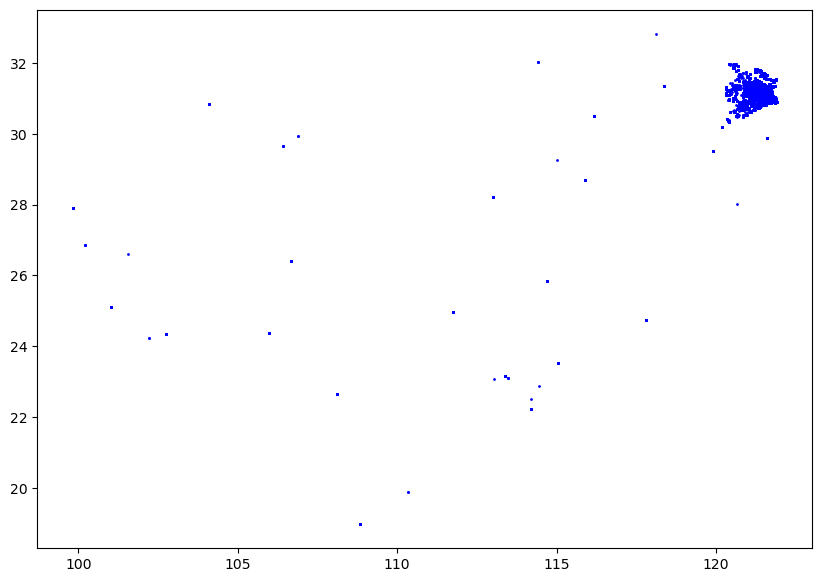

In [59]:
# Make sure you imported geopandas correctly
import geopandas as gpd

# Create the GeoDataFrame (correct alias: gpd, correct variable name: an_gpd)
an_gpd = gpd.GeoDataFrame(
    an_df, 
    geometry=gpd.points_from_xy(an_df.longitude, an_df.latitude), 
    crs=4326
)

# Now plot using the same variable name
an_gpd.plot(markersize=1, color='b', figsize=(10,10))

In [60]:
# ============================================
# Extraire les stations de métro depuis le POI
# ============================================
subway_poi = poi_df[poi_df['GBCODE'] == 200402].copy()  # Filtrer

print(f"Nombre de points métro (gpcode=200402) : {len(subway_poi)}")

# Créer le GeoDataFrame pour les stations de métro
subway_gdf = gpd.GeoDataFrame(
    subway_poi,
    geometry=gpd.points_from_xy(subway_poi.GPSX, subway_poi.GPSY),
    crs="EPSG:4326"
)



Nombre de points métro (gpcode=200402) : 1285


In [61]:
subway_poi.head()

,Unnamed: 0,ID,POIID,GCJX,GCJY,NAME,ADD,TEL,TYPE,AREAID,...,TYPE5,TYPE3.1,TYPE3.2,TYPE3.3,TYPE1.N,TYPE2.N,TYPE3.N,TYPE3.1.N,TYPECODE,GBCODE
69644,69645,44,BX10019657,121.318922,31.193864,虹桥火车站地铁站D出口,2号线;10号线,NaN,交通设施服务;地铁站;出入口,310112,...,NaN,出入口,NaN,NaN,72388,1706,1285,1285,交通设施服务;地铁站;出入口,200402.0
69645,69646,44,BX10019658,121.318111,31.194152,虹桥火车站地铁站E出口,2号线;10号线,NaN,交通设施服务;地铁站;出入口,310112,...,NaN,出入口,NaN,NaN,72388,1706,1285,1285,交通设施服务;地铁站;出入口,200402.0
69646,69647,44,BX10019659,121.319771,31.193917,虹桥火车站地铁站B出口,2号线;10号线,NaN,交通设施服务;地铁站;出入口,310112,...,NaN,出入口,NaN,NaN,72388,1706,1285,1285,交通设施服务;地铁站;出入口,200402.0
69647,69648,44,BX10019717,121.348136,31.154370,七宝地铁站4号口,9号线,NaN,交通设施服务;地铁站;出入口,310112,...,NaN,出入口,NaN,NaN,72388,1706,1285,1285,交通设施服务;地铁站;出入口,200402.0
69648,69649,44,BX10019718,121.232699,31.054166,松江大学城地铁站1号口,9号线,NaN,交通设施服务;地铁站;出入口,310117,...,NaN,出入口,NaN,NaN,72388,1706,1285,1285,交通设施服务;地铁站;出入口,200402.0


Skipping field center: unsupported OGR type: 3
Skipping field centroid: unsupported OGR type: 3
Skipping field acroutes: unsupported OGR type: 1


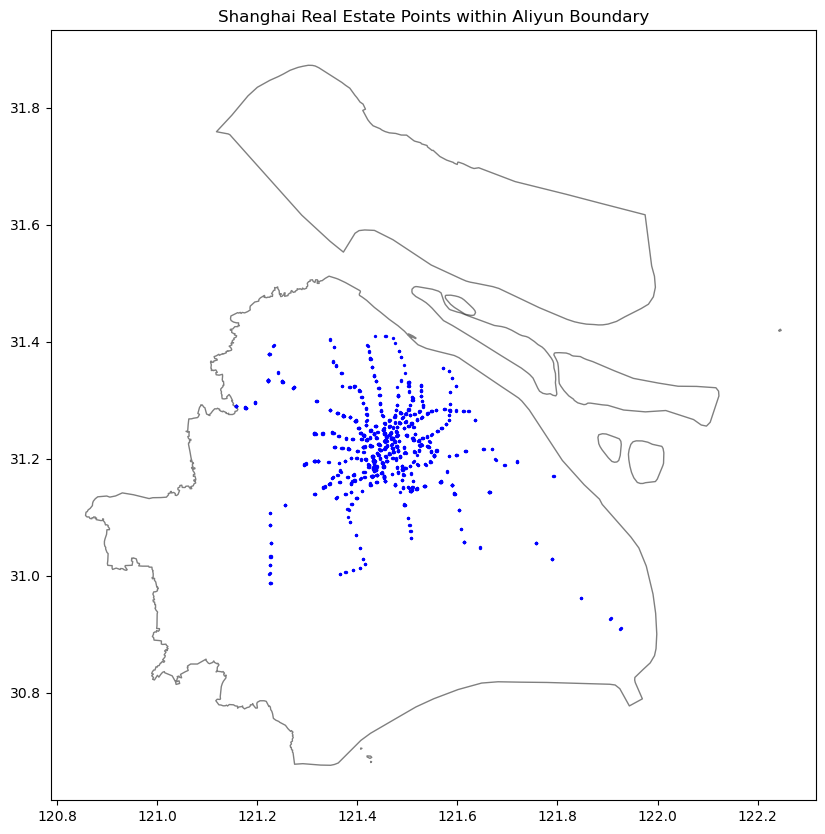

In [68]:
import geopandas as gpd
import matplotlib.pyplot as plt

# The URL for the Shanghai boundary (adcode: 310000) from Aliyun DataV GeoAtlas
aliyun_shanghai_url = "https://geo.datav.aliyun.com/areas_v3/bound/310000.json"

# Load the GeoJSON directly into a GeoDataFrame
shanghai_boundary = gpd.read_file(aliyun_shanghai_url)

# Ensure the boundary is in the same CRS (Coordinate Reference System) as your points
# Aliyun's GeoJSON is EPSG:4326 by default, matching your GPS points
if shanghai_boundary.crs != "EPSG:4326":
    shanghai_boundary = shanghai_boundary.to_crs("EPSG:4326")

# 2. Keep only the points inside the zone of Shanghai using gpd.clip()
anjuke_shanghai_gdf = gpd.clip(an_gpd, shanghai_boundary)
subway_exit_shanghai_gdf = gpd.clip(subway_gdf, shanghai_boundary)
# subway_station_shanghai_gdf = gpd.clip(subway_station_gdf, shanghai_boundary)

# 3. Plot to verify the results
fig, ax = plt.subplots(figsize=(10, 10))
# Plot the Aliyun Shanghai boundary
shanghai_boundary.plot(ax=ax, color='white', markersize=2, alpha=0.5, edgecolor='black', linewidth=1)
# Plot the filtered Anjuke real estate points
subway_exit_shanghai_gdf.plot(ax=ax, color='blue', markersize=2, alpha=1, label="Subway Exits")
# 

ax.set_title("Shanghai Real Estate Points within Aliyun Boundary")
plt.show()